In [1]:
import os
print(os.getcwd())


/Users/maceli/ifood_cs/code/notebook


In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append('..')

import utilities.functions as functions

from utilities.functions import (
    load_data,
    check_key_uniqueness,
    merge_df,
    load_orders,
    process_orders_pandas
)

In [3]:
from pathlib import Path
BASE_PATH = Path("/Users/maceli/ifood_cs/dados") 
df = pd.read_parquet(BASE_PATH / "silver" / "df_p_2.parquet").drop([ "delivery_address_district", "delivery_address_country",'customer_name','active','created_at','delivery_address_external_id'], axis=1)
df.head()

,customer_id,is_target,delivery_address_city,delivery_address_latitude,delivery_address_longitude,delivery_address_state,merchant_id,order_created_at,order_id,order_total_amount,origin_platform
0,6206f4b585fdd39a5a14bdbac75442a0cb728234d735cd...,target,RIBEIRAO PRETO,-47.83,-21.23,SP,9efa7e40269f04be813a7100582a23ecb3e9266d5d3932...,2019-01-26T15:48:09.000Z,d81ef123beb69b1a50a1c74883454d11c35016a5efa642...,25.0,DESKTOP
1,6206f4b585fdd39a5a14bdbac75442a0cb728234d735cd...,target,RIBEIRAO PRETO,-47.83,-21.23,SP,9efa7e40269f04be813a7100582a23ecb3e9266d5d3932...,2019-01-02T14:46:18.000Z,3d13dc27ccbbcc5c530dce062fbf849ae3b1e7f11a6a15...,50.6,DESKTOP
2,6206f4b585fdd39a5a14bdbac75442a0cb728234d735cd...,target,RIBEIRAO PRETO,-47.83,-21.23,SP,9efa7e40269f04be813a7100582a23ecb3e9266d5d3932...,2018-12-27T15:48:09.000Z,d81ef123beb69b1a50a1c74883454d11c35016a5efa642...,25.0,DESKTOP
3,6206f4b585fdd39a5a14bdbac75442a0cb728234d735cd...,target,RIBEIRAO PRETO,-47.83,-21.23,SP,9efa7e40269f04be813a7100582a23ecb3e9266d5d3932...,2018-12-03T14:46:18.000Z,3d13dc27ccbbcc5c530dce062fbf849ae3b1e7f11a6a15...,50.6,DESKTOP
4,ff4770f539de10af59e9f33b00fa740820b4b770c28692...,target,MARINGA,-51.92,-23.42,PR,7741b0fa300facf4081521b0f31d273aa72b4adc63f9de...,2019-01-01T23:23:38.000Z,8c3b6cd6feaa3e5858bd71c24029ce3fbb2231194da205...,17.0,IOS


Criando dias da semana, dia, hora

In [4]:
df["order_created_at"] = pd.to_datetime(df["order_created_at"], utc=True)
df["day_month_year"] = df["order_created_at"].dt.strftime("%d-%m-%Y")
df["weekday"] = df["order_created_at"].dt.day_name()
df["hour"] = df["order_created_at"].dt.hour
df["order_created_month"] = df["order_created_at"].dt.month
df["day"] = df["order_created_at"].dt.day


In [5]:
def gerar_stats(df, group_cols):
    """
    df         -> seu DataFrame original
    group_cols -> lista de colunas para agrupar (ex: ["weekday"], ["weekday","hour"], etc.)
    """

    df_stats_mes = (
        df.groupby(['order_created_month'] + group_cols)
          .agg(
              total_clientes=('customer_id', 'nunique'),
              total_pedidos=('order_id', 'count'),
              total_ordem=('order_total_amount', 'sum')
          )
          .reset_index()
          .assign(
              perc_clientes=lambda d: d.groupby('order_created_month')['total_clientes']
                                         .transform(lambda x: x / x.sum() * 100),
              perc_pedidos=lambda d: d.groupby('order_created_month')['total_pedidos']
                                        .transform(lambda x: x / x.sum() * 100),
              perc_amount=lambda d: d.groupby('order_created_month')['total_ordem']
                                         .transform(lambda x: x / x.sum() * 100)
          )
          .round(2)
          .sort_values(['order_created_month', 'total_clientes'], ascending=[True, False])
          .reset_index(drop=True)
    )

    return df_stats_mes


In [6]:
summary_mes=gerar_stats(df,['is_target','origin_platform'])
summary_mes

,order_created_month,is_target,origin_platform,total_clientes,total_pedidos,total_ordem,perc_clientes,perc_pedidos,perc_amount
0,1,target,ANDROID,67,176,7671.10,29.39,29.58,26.74
1,1,target,IOS,58,165,9021.20,25.44,27.73,31.44
2,1,control,IOS,35,98,4724.34,15.35,16.47,16.47
3,1,control,ANDROID,30,72,3126.38,13.16,12.10,10.90
4,1,control,DESKTOP,19,35,1830.90,8.33,5.88,6.38
5,1,target,DESKTOP,17,42,2080.79,7.46,7.06,7.25
6,1,control,WINDOWS_PHONE,2,7,237.40,0.88,1.18,0.83
7,12,target,ANDROID,64,106,4771.89,29.91,30.29,29.41
8,12,target,IOS,57,91,4431.46,26.64,26.00,27.31
9,12,control,IOS,34,56,2788.98,15.89,16.00,17.19


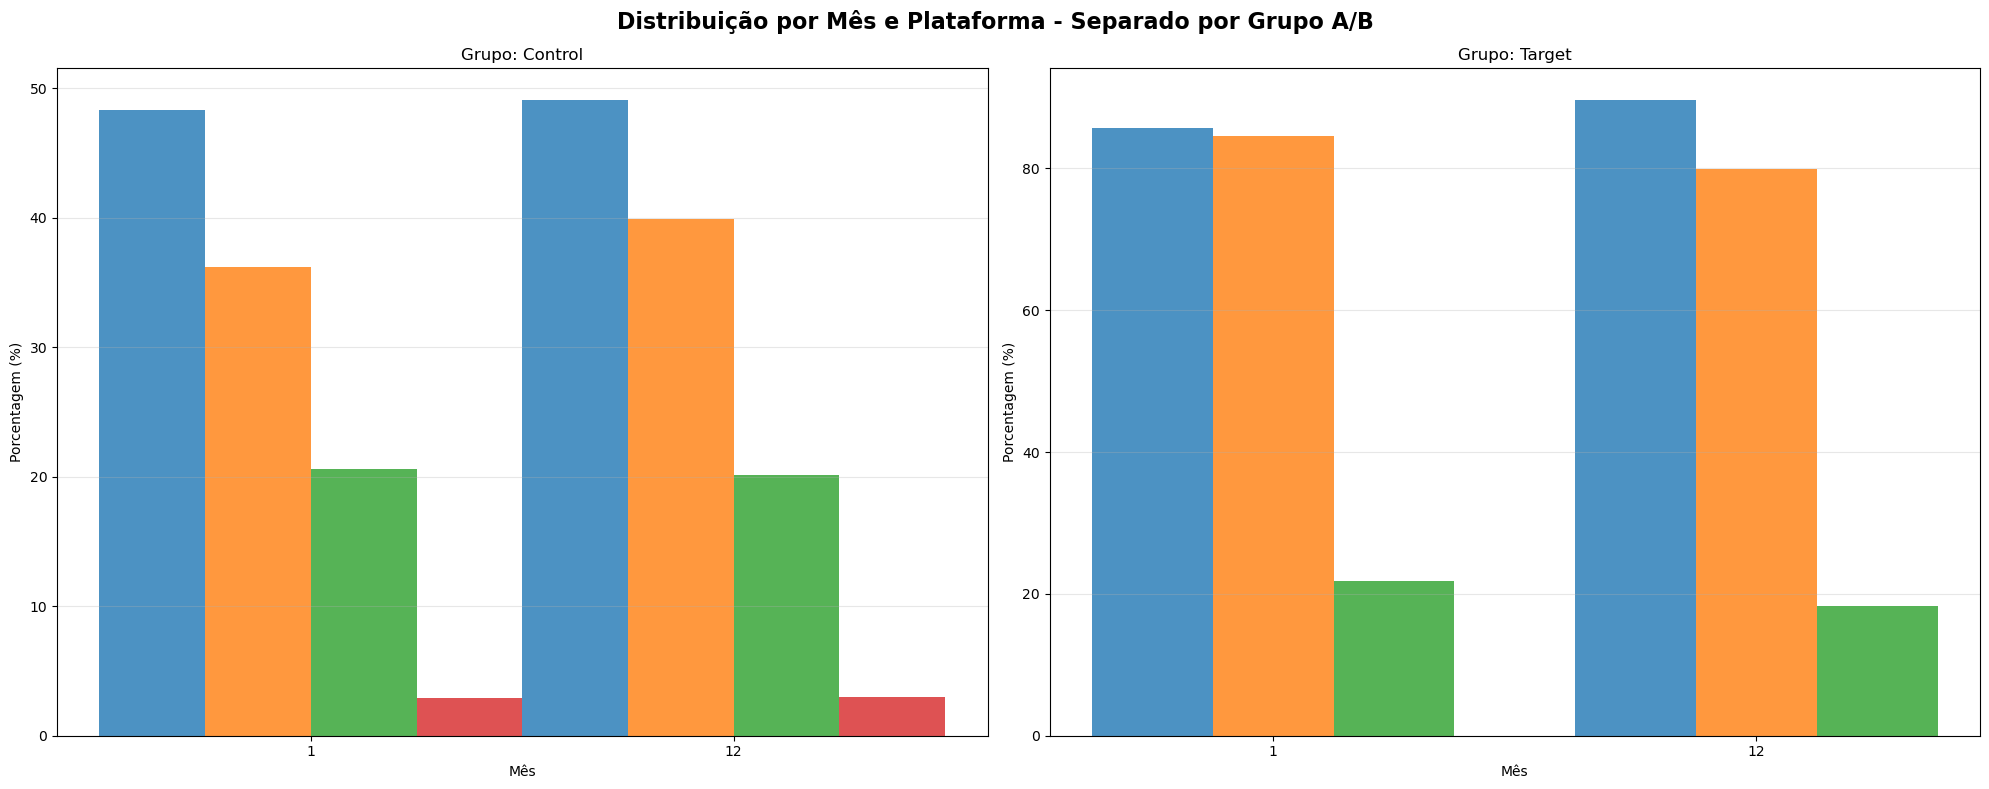

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Criar subplots para cada is_target
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Distribuição por Mês e Plataforma - Separado por Grupo A/B', fontsize=16, fontweight='bold')

# Para cada grupo (control e target)
for idx, target in enumerate(['control', 'target']):
    # Filtrar dados por is_target
    target_data = summary_mes[summary_mes['is_target'] == target]
    
    # Posições no eixo X
    meses = sorted(target_data['order_created_month'].unique())
    x = np.arange(len(meses))
    width = 0.25
    
    # Para cada plataforma
    platforms = target_data['origin_platform'].unique()
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(platforms)]
    
    for i, platform in enumerate(platforms):
        platform_data = target_data[target_data['origin_platform'] == platform]
        
        # Reordenar por mês
        platform_data = platform_data.set_index('order_created_month').reindex(meses).reset_index()
        
        # Barras empilhadas para as 3 métricas
        axes[idx].bar(x + i*width, platform_data['perc_clientes'], width, 
                     alpha=0.8, color=colors[i])
        
        axes[idx].bar(x + i*width, platform_data['perc_pedidos'], width, 
                     alpha=0.8, color=colors[i], 
                     bottom=platform_data['perc_clientes'])
        
        axes[idx].bar(x + i*width, platform_data['perc_amount'], width, 
                     alpha=0.8, color=colors[i],
                     bottom=platform_data['perc_clientes'] + platform_data['perc_pedidos'])
    
    axes[idx].set_xlabel('Mês')
    axes[idx].set_ylabel('Porcentagem (%)')
    axes[idx].set_title(f'Grupo: {target.title()}')
    axes[idx].set_xticks(x + width*(len(platforms)-1)/2)
    axes[idx].set_xticklabels(meses)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
df=df.sort_values(['order_created_month', 'day_month_year'])
#df=df[df["customer_id"]=='005f54ebf0a9afaaa6189281dc7f4e335ce71334cc63b59da397b4e2d5e0aa0e']


% de clientes com mais de um pedido - no mes %valor e % amount

In [9]:
# Análise completa por mês
df_analise_completa = (
    df.groupby(['order_created_month', 'customer_id'])
    .agg(
        total_pedidos=('order_id', 'count'),
        total_amount=('order_total_amount', 'sum')
    )
    .reset_index()
    .assign(categoria_pedidos=lambda x: x['total_pedidos'].apply(lambda y: '1_pedido' if y == 1 else '2+_pedidos'))
    .groupby(['order_created_month', 'categoria_pedidos'])
    .agg(
        total_clientes=('customer_id', 'nunique'),
        total_pedidos=('total_pedidos', 'sum'),
        total_amount=('total_amount', 'sum'),
        avg_amount_por_cliente=('total_amount', 'mean')
    )
    .reset_index()
)

# Calcular porcentagens
df_analise_completa = (
    df_analise_completa
    .merge(
        df_analise_completa.groupby('order_created_month')['total_clientes'].sum().rename('total_clientes_mes'),
        on='order_created_month'
    )
    .assign(
        perc_clientes=lambda x: (x['total_clientes'] / x['total_clientes_mes'] * 100).round(2),
        perc_pedidos=lambda x: (x['total_pedidos'] / x.groupby('order_created_month')['total_pedidos'].transform('sum') * 100).round(2),
        perc_amount=lambda x: (x['total_amount'] / x.groupby('order_created_month')['total_amount'].transform('sum') * 100).round(2)
    )
    .drop('total_clientes_mes', axis=1)
    .sort_values(['order_created_month', 'categoria_pedidos'])
    .reset_index(drop=True)
)

print(df_analise_completa)

   order_created_month categoria_pedidos  total_clientes  total_pedidos  \
0                    1        2+_pedidos             209            595   
1                   12          1_pedido              68             68   
2                   12        2+_pedidos             141            282   

   total_amount  avg_amount_por_cliente  perc_clientes  perc_pedidos  \
0      28692.11              137.282823         100.00        100.00   
1       3423.21               50.341324          32.54         19.43   
2      12801.19               90.788582          67.46         80.57   

   perc_amount  
0        100.0  
1         21.1  
2         78.9  


In [30]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calcular_poder_estatistico_ab(n_control, n_target, p_base, alpha=0.05, efeito_observado=None):
    """
    Calcula o poder estatístico e mínimo detectável de um teste A/B
    """
    # Valores Z
    z_alpha = norm.ppf(1 - alpha/2)  # Bicaudal
    z_beta = norm.ppf(0.8)  # 80% poder
    
    # Tamanho efetivo da amostra (média harmônica)
    n_eff = 2 / (1/n_control + 1/n_target)
    
    # Mínimo Detectável (MDE)
    var = p_base * (1 - p_base)
    mde = (z_alpha + z_beta) * math.sqrt(2 * var / n_eff)
    
    # Poder para efeito observado (se fornecido)
    poder_observado = None
    if efeito_observado:
        z_effect = efeito_observado / math.sqrt(2 * var / n_eff)
        poder_observado = norm.cdf(z_effect - z_alpha) + norm.cdf(-z_effect - z_alpha)
    
    return {
        'mde_absoluto': mde,
        'mde_relativo': mde / p_base,
        'poder_observado': poder_observado,
        'n_efetivo': n_eff,
        'conversao_minima_detectavel': p_base + mde
    }

def analisar_poder_teste(df):
    """
    Analisa o poder estatístico do teste A/B atual
    """
    from scipy.stats import norm
    
    # Estimar conversão base
    clientes_jan = df[
        (df['rank_month'] == 1) & 
        (df['order_created_month'] == 1)
    ].drop_duplicates(['customer_id', 'order_created_month'])
    
    # Clientes que converteram em até 30 dias (visão mais ampla)
    clientes_convertidos = df[
        (df['rank_month'] == 2) & 
        (df['order_created_month'] == 1) & 
        (df['days_between_orders'] < 30)
    ].drop_duplicates(['customer_id', 'order_created_month'])
    
    clientes_jan['converteu'] = clientes_jan['customer_id'].isin(clientes_convertidos['customer_id'])
    
    # Estatísticas por grupo
    stats_grupo = clientes_jan.groupby('is_target').agg({
        'customer_id': 'nunique',
        'converteu': 'sum'
    }).assign(
        taxa_conversao=lambda x: x['converteu'] / x['customer_id']
    )
    
    n_control = stats_grupo.loc['control', 'customer_id']
    n_target = stats_grupo.loc['target', 'customer_id'] 
    p_base = stats_grupo['converteu'].sum() / stats_grupo['customer_id'].sum()
    efeito_observado = stats_grupo.loc['target', 'taxa_conversao'] - stats_grupo.loc['control', 'taxa_conversao']
    
    # Calcular poder
    resultado_poder = calcular_poder_estatistico_ab(n_control, n_target, p_base, efeito_observado=efeito_observado)
    
    return resultado_poder, stats_grupo, n_control, n_target, p_base, efeito_observado

def simular_amostras_necessarias(p_base, efeitos_desejados=[0.05, 0.10, 0.15], alpha=0.05, poder=0.8):
    """
    Simula tamanhos de amostra necessários para diferentes efeitos
    """
    z_alpha = norm.ppf(1 - alpha/2)
    z_beta = norm.ppf(poder)
    var = p_base * (1 - p_base)
    
    resultados = []
    for efeito in efeitos_desejados:
        n_necessario = ((z_alpha + z_beta)**2 * 2 * var) / (efeito**2)
        resultados.append({
            'efeito_desejado': efeito,
            'efeito_percentual': f"+{efeito/p_base*100:.1f}%",
            'amostra_por_grupo': math.ceil(n_necessario),
            'total_clientes': math.ceil(n_necessario) * 2
        })
    
    return pd.DataFrame(resultados)

# EXECUTAR ANÁLISE
print("🔍 ANALISANDO PODER ESTATÍSTICO DO TESTE A/B ATUAL")
print("=" * 60)

resultado_poder, stats_grupo, n_control, n_target, p_base, efeito_observado = analisar_poder_teste(df)

print(f"📊 DADOS ATUAIS:")
print(f"• Grupo Control: {n_control} clientes")
print(f"• Grupo Target: {n_target} clientes") 
print(f"• Conversão base: {p_base:.1%}")
print(f"• Efeito observado: {efeito_observado:+.3f}")

print(f"\n🎯 PODER ESTATÍSTICO:")
print(f"• Mínimo Detectável (MDE): {resultado_poder['mde_absoluto']:.1%}")
print(f"• Conversão mínima detectável: {resultado_poder['conversao_minima_detectavel']:.1%}")
print(f"• Poder para efeito observado: {resultado_poder['poder_observado']:.1%}" if resultado_poder['poder_observado'] else "• Efeito muito pequeno para detectar")

print(f"\n⚠️  DIAGNÓSTICO:")
if resultado_poder['poder_observado'] and resultado_poder['poder_observado'] < 0.8:
    print("❌ TESTE SEM PODER - Não consegue detectar efeitos realistas")
elif abs(efeito_observado) < resultado_poder['mde_absoluto']:
    print("❌ EFEITO MUITO PEQUENO - Diferença observada está abaixo do MDE")
else:
    print("✅ TESTE COM PODER SUFICIENTE")

# SIMULAR AMOSTRAS NECESSÁRIAS
print(f"\n📈 AMOSTRAS NECESSÁRIAS PARA TESTES FUTUROS:")
amostras_necessarias = simular_amostras_necessarias(p_base)
print(amostras_necessarias.to_string(index=False))

# GRÁFICO DE PODER
print(f"\n📊 GRÁFICO DE PODER ESTATÍSTICO (Salvo como 'poder_estatistico.png')")

def plotar_poder_estatistico(p_base, n_control, n_target):
    efeitos = np.arange(0.01, 0.31, 0.01)
    poderes = []
    
    for efeito in efeitos:
        resultado = calcular_poder_estatistico_ab(n_control, n_target, p_base, efeito_observado=efeito)
        poderes.append(resultado['poder_observado'])
    
    plt.figure(figsize=(10, 6))
    plt.plot(efeitos/p_base*100, poderes, linewidth=2)
    plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='Poder mínimo (80%)')
    plt.axvline(x=resultado_poder['mde_absoluto']/p_base*100, color='orange', linestyle='--', 
                label=f'MDE atual ({resultado_poder["mde_absoluto"]/p_base*100:.1f}%)')
    plt.xlabel('Aumento Relativo na Conversão (%)')
    plt.ylabel('Poder Estatístico')
    plt.title('Poder Estatístico vs Tamanho do Efeito')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('poder_estatistico.png', dpi=300, bbox_inches='tight')
    plt.show()

plotar_poder_estatistico(p_base, n_control, n_target)

# RECOMENDAÇÕES PRÁTICAS
print(f"\n💡 RECOMENDAÇÕES:")
if n_control + n_target < 1000:
    print("1. 📈 AUMENTE A AMOSTRA: Colete mais dados ou espere mais tempo")
print("2. 🎯 FOQUE EM EFEITOS MAIORES: Teste mudanças mais agressivas")
print("3. 📊 AGRUPE DADOS: Combine múltiplos meses para aumentar poder")
print("4. 🔍 SEGMENTE: Teste em subgrupos específicos com maior potencial")
print("5. ⏱️  PLANEJE: Use as amostras calculadas para próximos testes")

print(f"\n🎯 PRÓXIMOS PASSOS:")
print(f"• Para detectar +5% relativo: {amostras_necessarias.iloc[0]['total_clientes']} clientes totais")
print(f"• Para detectar +10% relativo: {amostras_necessarias.iloc[1]['total_clientes']} clientes totais")

🔍 ANALISANDO PODER ESTATÍSTICO DO TESTE A/B ATUAL


NameError: name 'norm' is not defined

Para clientes com mais de um pedido no

In [10]:
# Análise detalhada por número exato de pedidos POR MÊS
df_analise_mensal = (
    df.groupby(['order_created_month', 'customer_id'])
    .agg(
        total_pedidos_mes=('order_id', 'count'),
        total_amount_mes=('order_total_amount', 'sum')
    )
    .reset_index()
    .assign(
        categoria_pedidos=lambda x: x['total_pedidos_mes'].apply(
            lambda y: str(y) if y <= 4 else '5+_pedidos'
        )
    )
    .groupby(['order_created_month', 'categoria_pedidos'])
    .agg(
        total_clientes=('customer_id', 'nunique'),
        total_pedidos_grupo=('total_pedidos_mes', 'sum'),
        total_amount=('total_amount_mes', 'sum'),
        avg_amount_por_cliente=('total_amount_mes', 'mean'),
        avg_pedidos_por_cliente=('total_pedidos_mes', 'mean')
    )
    .reset_index()
)

# Calcular totais mensais para porcentagens
totais_mensais = (
    df_analise_mensal.groupby('order_created_month')
    .agg(
        total_clientes_mes=('total_clientes', 'sum'),
        total_pedidos_mes=('total_pedidos_grupo', 'sum'),
        total_amount_mes=('total_amount', 'sum')
    )
    .reset_index()
)

# Juntar e calcular porcentagens
df_analise_mensal = (
    df_analise_mensal
    .merge(totais_mensais, on='order_created_month')
    .assign(
        perc_clientes=lambda x: (x['total_clientes'] / x['total_clientes_mes'] * 100).round(2),
        perc_pedidos=lambda x: (x['total_pedidos_grupo'] / x['total_pedidos_mes'] * 100).round(2),
        perc_amount=lambda x: (x['total_amount'] / x['total_amount_mes'] * 100).round(2),
        avg_amount_por_pedido=lambda x: (x['total_amount'] / x['total_pedidos_grupo']).round(2)
    )
    .drop(['total_clientes_mes', 'total_pedidos_mes', 'total_amount_mes'], axis=1)
    .sort_values(['order_created_month', 'categoria_pedidos'])
    .reset_index(drop=True)
)

print("Análise detalhada por número de pedidos POR MÊS:")
#print(df_analise_mensal)
df_analise_mensal

Análise detalhada por número de pedidos POR MÊS:


,order_created_month,categoria_pedidos,total_clientes,total_pedidos_grupo,total_amount,avg_amount_por_cliente,avg_pedidos_por_cliente,perc_clientes,perc_pedidos,perc_amount,avg_amount_por_pedido
0,1,2,139,278,12970.93,93.316043,2.000000,66.51,46.72,45.21,46.66
1,1,3,22,66,3319.61,150.891364,3.000000,10.53,11.09,11.57,50.30
2,1,4,20,80,3273.31,163.665500,4.000000,9.57,13.45,11.41,40.92
3,1,5+_pedidos,28,171,9128.26,326.009286,6.107143,13.40,28.74,31.81,53.38
4,12,1,68,68,3423.21,50.341324,1.000000,32.54,19.43,21.10,50.34
5,12,2,141,282,12801.19,90.788582,2.000000,67.46,80.57,78.90,45.39


In [11]:
# Ordenar por datetime completo
df = df.sort_values(['customer_id', 'order_created_at'])

# 1. Rank por ordem cronológica dentro do mês
df["rank_month"] = df.groupby(["customer_id", "order_created_month"]).cumcount() + 1

# 2. Diferença em DIAS entre ordens consecutivas
df['days_between_orders'] = (
    df.groupby(['customer_id', 'order_created_month'])['order_created_at']
    .diff()
).dt.days

# 3. Dias desde a primeira ordem do mês
df['days_since_first_order_month'] = (
    df.groupby(['customer_id', 'order_created_month'])['order_created_at']
    .transform(lambda x: (x - x.min()).dt.days)
)

# 4. VALOR da diferença entre ordens consecutivas
df['amount_diff_from_previous'] = (
    df.groupby(['customer_id', 'order_created_month'])['order_total_amount']
    .diff()
)

# 5. % de variação do valor em relação à ordem anterior
df['amount_pct_change_from_previous'] = (
    df.groupby(['customer_id', 'order_created_month'])['order_total_amount']
    .pct_change() * 100
)

# 6. Diferença em dias até a PRÓXIMA ordem (se existir)
df['days_until_next_order'] = (
    df.groupby(['customer_id', 'order_created_month'])['order_created_at']
    .shift(-1) - df['order_created_at']
).dt.days

# 7. É a ÚLTIMA ordem do mês?
df['is_last_order_month'] = (
    df.groupby(['customer_id', 'order_created_month'])['order_created_at']
    .transform(lambda x: x == x.max())
)

# Preencher NaN com 0
df['days_between_orders'] = df['days_between_orders'].fillna(0)
df['amount_diff_from_previous'] = df['amount_diff_from_previous'].fillna(0)
df['amount_pct_change_from_previous'] = df['amount_pct_change_from_previous'].fillna(0)
df['days_until_next_order'] = df['days_until_next_order'].fillna(-999)  # -1 indica que não há próxima ordem

percentual_desconto = 0.3

df['%desconto'] = np.where(
    (df['rank_month'] == 2), 
    df['order_total_amount'] * percentual_desconto,
    0.0
)
# Filtrar apenas as segundas ordens de cada mês
second_orders = df[df['rank_month'] == 2]
percentual_desconto = 0.3

# Correção: referenciar a coluna corretamente


# Mostrar amostra

# Calcular a média dos dias entre a primeira e segunda ordem
avg_days_first_to_second = second_orders['days_since_first_order_month'].mean()
print(f"Tempo médio entre 1ª e 2ª ordem: {avg_days_first_to_second:.2f} dias")



# Dados gerais
total_ordens_com_anterior = len(df[df['rank_month'] > 1])
ordens_maiores = len(df[(df['rank_month'] > 1) & (df['amount_diff_from_previous'] > 0)])
ordens_menores = len(df[(df['rank_month'] > 1) & (df['amount_diff_from_previous'] < 0)])
ordens_iguais = len(df[(df['rank_month'] > 1) & (df['amount_diff_from_previous'] == 0)])

pct_maiores = (ordens_maiores / total_ordens_com_anterior) * 100
pct_menores = (ordens_menores / total_ordens_com_anterior) * 100
pct_iguais = (ordens_iguais / total_ordens_com_anterior) * 100



# Segundas ordens especificamente
total_segundas = len(second_orders)
segundas_maiores = len(second_orders[second_orders['amount_diff_from_previous'] > 0])
segundas_menores = len(second_orders[second_orders['amount_diff_from_previous'] < 0])
segundas_iguais = len(second_orders[second_orders['amount_diff_from_previous'] == 0])

pct_segundas_maiores = (segundas_maiores / total_segundas) * 100
pct_segundas_menores = (segundas_menores / total_segundas) * 100
pct_segundas_iguais = (segundas_iguais / total_segundas) * 100



Tempo médio entre 1ª e 2ª ordem: 7.42 dias


In [12]:
df_g = (
        second_orders.groupby(['order_created_month','days_since_first_order_month'])
          .agg(
              total_clientes=('customer_id', 'nunique'),
              total_pedidos=('order_id', 'count'),
              total_ordem=('order_total_amount', 'sum')
          )
          .reset_index()
          .assign(
              perc_clientes=lambda d: d.groupby('order_created_month')['total_clientes']
                                         .transform(lambda x: x / x.sum() * 100),
              perc_pedidos=lambda d: d.groupby('order_created_month')['total_pedidos']
                                        .transform(lambda x: x / x.sum() * 100),
              perc_amount=lambda d: d.groupby('order_created_month')['total_ordem']
                                         .transform(lambda x: x / x.sum() * 100)
          )
          .round(2)
          .sort_values(['order_created_month','days_since_first_order_month'], ascending=[True,True])
          .reset_index(drop=True)
    )
df_g.head(10)

,order_created_month,days_since_first_order_month,total_clientes,total_pedidos,total_ordem,perc_clientes,perc_pedidos,perc_amount
0,1,0,32,32,1132.65,15.31,15.31,11.60
1,1,1,21,21,1149.26,10.05,10.05,11.77
2,1,2,16,16,677.65,7.66,7.66,6.94
3,1,3,14,14,806.42,6.70,6.70,8.26
4,1,4,8,8,366.70,3.83,3.83,3.76
5,1,5,19,19,814.50,9.09,9.09,8.34
6,1,6,8,8,357.12,3.83,3.83,3.66
7,1,7,8,8,350.30,3.83,3.83,3.59
8,1,8,8,8,286.40,3.83,3.83,2.93
9,1,9,8,8,380.41,3.83,3.83,3.90


Conversao imediata

In [13]:
df=df[['customer_id','order_created_month','is_target','rank_month','order_total_amount','days_between_orders']]

In [28]:
import pandas as pd
import numpy as np

def analisar_teste_ab(df, dias_limite, percentual_desconto):
    """
    Analisa teste A/B para diferentes janelas de tempo e percentuais de desconto
    """
    clientes_voltaram_com_grupo = (
        df[
            (df['rank_month'] == 1) & 
            (df['order_created_month'] == 1)
        ]
        .drop_duplicates(['customer_id', 'order_created_month'])
        .merge(
            df[
                (df['rank_month'] == 2) & 
                (df['order_created_month'] == 1) & 
                (df['days_between_orders'] <= dias_limite)
            ]
            .drop_duplicates(['customer_id', 'order_created_month'])
            .assign(
                converteu=True,
                **{'%desconto': lambda x: np.where(
                    x['is_target'] == 'target', 
                    x['order_total_amount'] * percentual_desconto, 
                    0.0
                )}
            )[['customer_id', 'converteu', '%desconto']],
            on='customer_id',
            how='left'
        )
        .assign(
            converteu=lambda x: x['converteu'].fillna(False),
            **{'%desconto': lambda x: x['%desconto'].fillna(0.0)}
        )
    )

    conversao_por_grupo = (
        clientes_voltaram_com_grupo.groupby('is_target')
        .agg(
            total_clientes=('customer_id', 'nunique'),
            clientes_converteram=('converteu', 'sum'),
            total_amount_mes=('order_total_amount', 'sum'),
            total_desconto=('%desconto', 'sum')
        )
        .assign(
            taxa_conversao=lambda x: (x['clientes_converteram'] / x['total_clientes'] * 100).round(2),
            diferenca_com_desconto=lambda x: x['total_amount_mes'] - x['total_desconto'],
            dias_limite=dias_limite,
            percentual_desconto=percentual_desconto
        )
        .reset_index()
    )
    
    return conversao_por_grupo

# TESTAR VÁRIAS COMBINAÇÕES
resultados = []

# Testar diferentes janelas de dias
dias_testar = [0,1, 3, 5, 7, 10]
# Testar diferentes percentuais de desconto
descontos_testar = [0.1, 0.15, 0.2, 0.25, 0.3]

for dias in dias_testar:
    for desconto in descontos_testar:
        resultado = analisar_teste_ab(df, dias, desconto)
        resultados.append(resultado)

# Combinar todos os resultados
resultados_combinados = pd.concat(resultados)

# VER TODOS OS RESULTADOS
print("📊 TODOS OS RESULTADOS (25 combinações):")
print("=" * 80)

# Ordenar por dias e desconto para melhor visualização
resultados_ordenados = resultados_combinados.sort_values(['dias_limite', 'percentual_desconto', 'is_target'])

# Mostrar todos os resultados formatados
for dias in dias_testar:
    print(f"\n🎯 JANELA DE {dias} DIAS:")
    print("-" * 50)
    
    resultados_dia = resultados_ordenados[resultados_ordenados['dias_limite'] == dias]
    
    for desconto in descontos_testar:
        print(f"\n📈 DESCONTO {desconto:.0%}:")
        resultados_desconto = resultados_dia[resultados_dia['percentual_desconto'] == desconto]
        
        for _, row in resultados_desconto.iterrows():
            grupo = row['is_target']
            conversao = row['taxa_conversao']
            diferenca = row['diferenca_com_desconto']
            custo = row['total_desconto']
            
            print(f"   {grupo:8} | Conversão: {conversao:5}% | Receita Líq: R$ {diferenca:8,.2f} | Custo: R$ {custo:6,.2f}")

# RESUMO GERAL
print("\n" + "=" * 80)
print("📈 RESUMO GERAL - TODOS OS CENÁRIOS")
print("=" * 80)

print(f"\nTotal de combinações testadas: {len(resultados_combinados)}")
print(f"Janelas de dias: {dias_testar}")
print(f"Percentuais de desconto: {[f'{d:.0%}' for d in descontos_testar]}")

# Melhores cenários por métrica
print(f"\n🏆 MELHOR CONVERSÃO (Target):")
melhor_conversao = resultados_combinados[resultados_combinados['is_target'] == 'target'].nlargest(1, 'taxa_conversao')
for _, row in melhor_conversao.iterrows():
    print(f"   {row['dias_limite']} dias | {row['percentual_desconto']:.0%} desconto | {row['taxa_conversao']}% conversão")

print(f"\n💰 MAIS LUCRATIVO (Target):")
mais_lucrativo = resultados_combinados[resultados_combinados['is_target'] == 'target'].nlargest(1, 'diferenca_com_desconto')
for _, row in mais_lucrativo.iterrows():
    print(f"   {row['dias_limite']} dias | {row['percentual_desconto']:.0%} desconto | R$ {row['diferenca_com_desconto']:,.2f}")

print(f"\n💸 MENOR CUSTO (Target):")
menor_custo = resultados_combinados[resultados_combinados['is_target'] == 'target'].nsmallest(1, 'total_desconto')
for _, row in menor_custo.iterrows():
    print(f"   {row['dias_limite']} dias | {row['percentual_desconto']:.0%} desconto | R$ {row['total_desconto']:,.2f}")

# Exportar para análise detalhada
resultados_combinados.to_csv('resultados_teste_ab_completo.csv', index=False)
print(f"\n💾 Resultados exportados para 'resultados_teste_ab_completo.csv'")

/var/folders/s5/dkrzm08d6wl79n0by4mcn72m0000gn/T/ipykernel_20626/1031857347.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  converteu=lambda x: x['converteu'].fillna(False),
/var/folders/s5/dkrzm08d6wl79n0by4mcn72m0000gn/T/ipykernel_20626/1031857347.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  converteu=lambda x: x['converteu'].fillna(False),
/var/folders/s5/dkrzm08d6wl79n0by4mcn72m0000gn/T/ipykernel_20626/1031857347.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future ver

📊 TODOS OS RESULTADOS (25 combinações):

🎯 JANELA DE 0 DIAS:
--------------------------------------------------

📈 DESCONTO 10%:
   control  | Conversão: 16.88% | Receita Líq: R$ 3,575.39 | Custo: R$   0.00
   target   | Conversão: 14.39% | Receita Líq: R$ 6,365.52 | Custo: R$  69.09

📈 DESCONTO 15%:
   control  | Conversão: 16.88% | Receita Líq: R$ 3,575.39 | Custo: R$   0.00
   target   | Conversão: 14.39% | Receita Líq: R$ 6,330.98 | Custo: R$ 103.64

📈 DESCONTO 20%:
   control  | Conversão: 16.88% | Receita Líq: R$ 3,575.39 | Custo: R$   0.00
   target   | Conversão: 14.39% | Receita Líq: R$ 6,296.43 | Custo: R$ 138.19

📈 DESCONTO 25%:
   control  | Conversão: 16.88% | Receita Líq: R$ 3,575.39 | Custo: R$   0.00
   target   | Conversão: 14.39% | Receita Líq: R$ 6,261.88 | Custo: R$ 172.74

📈 DESCONTO 30%:
   control  | Conversão: 16.88% | Receita Líq: R$ 3,575.39 | Custo: R$   0.00
   target   | Conversão: 14.39% | Receita Líq: R$ 6,227.34 | Custo: R$ 207.28

🎯 JANELA DE 1 DIAS:
--

/var/folders/s5/dkrzm08d6wl79n0by4mcn72m0000gn/T/ipykernel_20626/1031857347.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  converteu=lambda x: x['converteu'].fillna(False),
/var/folders/s5/dkrzm08d6wl79n0by4mcn72m0000gn/T/ipykernel_20626/1031857347.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  converteu=lambda x: x['converteu'].fillna(False),
/var/folders/s5/dkrzm08d6wl79n0by4mcn72m0000gn/T/ipykernel_20626/1031857347.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future ver

In [ ]:



conversao_por_grupo = (
    clientes_voltaram_com_grupo.groupby('is_target')
    .agg(
        total_clientes=('customer_id', 'nunique'),
        clientes_converteram=('converteu', 'sum'),
        total_amount_mes=('order_total_amount', 'sum'),
        total_desconto=('%desconto', 'sum')
    )
    .assign(
        taxa_conversao=lambda x: (x['clientes_converteram'] / x['total_clientes'] * 100).round(2),
        diferenca_com_desconto=lambda x: x['total_amount_mes'] - x['total_desconto']
    )
)

conversao_por_grupo

,total_clientes,clientes_converteram,total_amount_mes,total_desconto,taxa_conversao,diferenca_com_desconto
is_target,,,,,,
control,77,13,3575.39,0.000,16.88,3575.390
target,132,19,6434.62,207.285,14.39,6227.335


Clientes com um unico pedido

In [29]:
x = 1 # Exemplo: clientes com 2 pedidos

df_clientes_x_pedidos = (
    df[df['order_created_month'] == 12]
    .groupby(['customer_id', 'order_created_month'])
    .agg(
        quantidade_pedidos=('order_id', 'count')
    )
    .reset_index()
    .query(f'quantidade_pedidos == {x}')
)


KeyError: "Column(s) ['order_id'] do not exist"

In [ ]:
df_=df[['customer_id','order_created_month','merchant_id','order_created_at','days_until_next_order','rank_month','order_total_amount','amount_pct_change_from_previous','amount_diff_from_previous']]

In [ ]:
# 1. Valor das 2ªs ordens COM cupom
valor_segundas_ordens = df[df['rank_month'] == 2]['order_total_amount'].sum()

# 2. Custo total do cupom
custo_cupom = df[df['rank_month'] == 2]['%desconto'].sum()

# 3. Receita líquida das 2ªs ordens
receita_liquida = valor_segundas_ordens - custo_cupom

print("💰 IMPACTO DO CUPOM NA 2ª ORDEM:")
print(f"• Valor bruto das 2ªs ordens: R$ {valor_segundas_ordens:,.2f}")
print(f"• Custo do cupom: R$ {custo_cupom:,.2f}")
print(f"• Receita líquida: R$ {receita_liquida:,.2f}")
print(f"• % do custo sobre a receita: {(custo_cupom/valor_segundas_ordens*100):.1f}%")

In [ ]:


# Mostrar amostra
df[['customer_id', 'order_created_month','order_created_month' ,'rank_month', 'order_total_amount', '%desconto']].head(10)

In [ ]:
# Filtrar a base df apenas com os clientes que têm X pedidos
df_filtrado = df_[
    (df_['customer_id'].isin(df_clientes_x_pedidos['customer_id'])) #& 
    #(df['order_created_month'] == 12)
]
#df_filtrado.sort_values('amount_pct_change_from_previous')

In [ ]:
df_filtrado.head()

In [ ]:
from lifelines.statistics import logrank_test

# Supondo que você tem analysis_df com:
# - customer_id (identificador único)
# - grupo_ab ('A' ou 'B') 
# - tempo_ate_segunda (dias)
# - fez_segunda_ordem (True/False)

# Separar os grupos
grupo_a = clientes_unicos_primeiro_pedido[clientes_unicos_primeiro_pedido['is_target'] == 'target']
grupo_b = clientes_unicos_primeiro_pedido[clientes_unicos_primeiro_pedido['is_target'] == 'contol']

print(f"Grupo A: {len(grupo_a)} clientes")
print(f"Grupo B: {len(grupo_b)} clientes")

# Teste de Log-Rank
results = logrank_test(
    grupo_a['tempo_ate_segunda'], 
    grupo_b['tempo_ate_segunda'],
    event_observed_A=grupo_a['fez_segunda_ordem'],
    event_observed_B=grupo_b['fez_segunda_ordem']
)

print("\n=== TESTE DE LOG-RANK ===")
print(f"p-value: {results.p_value:.4f}")
print(f"Significativo (p < 0.05): {results.p_value < 0.05}")

if results.p_value < 0.05:
    print("✅ Há diferença significativa entre os grupos!")
else:
    print("❌ Não há diferença significativa entre os grupos")

In [ ]:
# Só precisa das contagens totais
from scipy.stats import chi2_contingency

# Criar tabela manualmente se não tiver o dataset
tabela = np.array([
    [len(grupo_a[grupo_a['fez_segunda_ordem'] == False]),  # Grupo A não converteu
     len(grupo_a[grupo_a['fez_segunda_ordem'] == True])],   # Grupo A converteu
    
    [len(grupo_b[grupo_b['fez_segunda_ordem'] == False]),  # Grupo B não converteu  
     len(grupo_b[grupo_b['fez_segunda_ordem'] == True])]    # Grupo B converteu
])

chi2, p_value, dof, expected = chi2_contingency(tabela)

In [ ]:
conversao_ab

In [ ]:
from scipy.stats import chi2_contingency

# Tabela de contingência
tabela = pd.crosstab(analysis_df['grupo_ab'], analysis_df['fez_segunda_ordem'])
print("=== TABELA DE CONTINGÊNCIA ===")
print(tabela)

# Teste Chi-Quadrado
chi2, p_value, dof, expected = chi2_contingency(tabela)
print(f"\n=== TESTE CHI-QUADRADO ===")
print(f"Chi2: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Significativo (p < 0.05): {p_value < 0.05}")

In [ ]:
df.head()

In [ ]:
from datetime import datetime
data_inicio = datetime(2024, 1, 1)
data_inicio

In [ ]:
clientes_ativos_janeiro = df[df['order_created_month'] == 1]['customer_id'].unique()
df_clientes_jan = df[df['customer_id'].isin(clientes_ativos_janeiro)].copy()

In [ ]:
df=df[df['order_created_month'] == 1]

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Clientes ativos em janeiro de 2019 (fizeram pelo menos 1 pedido em jan/2019)
clientes_ativos_janeiro = df[
    (df['order_created_month'] == 1) & 
    (df['order_created_at'].dt.year == 2019)
]['customer_id'].unique()

print(f"Total de clientes ativos em janeiro de 2019: {len(clientes_ativos_janeiro)}")

# Filtrar TODOS os pedidos desses clientes
df_clientes_jan = df[df['customer_id'].isin(clientes_ativos_janeiro)].copy()

# Preparar dados para análise de sobrevivência CORRETA
analysis_data = []

for customer_id in clientes_ativos_janeiro:
    customer_orders = df_clientes_jan[df_clientes_jan['customer_id'] == customer_id].sort_values('order_created_at')
    
    # Primeira ordem do cliente em janeiro de 2019
    ordens_janeiro_2019 = customer_orders[
        (customer_orders['order_created_month'] == 1) & 
        (customer_orders['order_created_at'].dt.year == 2019)
    ]
    
    if len(ordens_janeiro_2019) >= 1:
        primeira_ordem_jan = ordens_janeiro_2019.iloc[0]
        data_primeira_ordem = primeira_ordem_jan['order_created_at']
        
        # Verificar se fez segunda ordem (em qualquer mês/ano)
        fez_segunda_ordem = len(customer_orders) >= 2
        
        if fez_segunda_ordem:
            segunda_ordem = customer_orders.iloc[1]
            data_segunda_ordem = segunda_ordem['order_created_at']
            
            # CORREÇÃO: Calcular tempo ENTRE 1ª e 2ª ordem
            tempo_ate_segunda = (data_segunda_ordem - data_primeira_ordem).days
            
            # Garantir que não seja negativo
            if tempo_ate_segunda < 0:
                print(f"AVISO: Tempo negativo para cliente {customer_id}")
                tempo_ate_segunda = 0
        else:
            # Cliente não fez segunda ordem - censurar após período razoável
            tempo_ate_segunda = 90  # Censurar em 90 dias
            fez_segunda_ordem = False
        
        analysis_data.append({
            'customer_id': customer_id,
            'grupo_ab': primeira_ordem_jan.get('grupo_ab', 'unknown'),
            'tempo_ate_segunda': tempo_ate_segunda,
            'fez_segunda_ordem': fez_segunda_ordem,
            'data_primeira_ordem': data_primeira_ordem
        })

# Criar DataFrame de análise
analysis_df = pd.DataFrame(analysis_data)

print(f"Clientes na análise: {len(analysis_df)}")
print(f"Clientes que fizeram 2ª ordem: {analysis_df['fez_segunda_ordem'].sum()}")
print(f"Taxa de conversão: {analysis_df['fez_segunda_ordem'].mean():.2%}")

# Verificar se há tempos negativos
if (analysis_df['tempo_ate_segunda'] < 0).any():
    print("⚠️  AVISO: Ainda há tempos negativos!")
    print(analysis_df[analysis_df['tempo_ate_segunda'] < 0])

# Aplicar Kaplan-Meier
kmf = KaplanMeierFitter()
kmf.fit(
    durations=analysis_df['tempo_ate_segunda'],
    event_observed=analysis_df['fez_segunda_ordem']
)

# Plotar
plt.figure(figsize=(12, 8))
kmf.plot_survival_function()
plt.title('Tempo entre 1ª e 2ª Ordem\n(Clientes Janeiro 2019)')
plt.ylabel('Probabilidade de Ainda Não Ter Feito 2ª Ordem')
plt.xlabel('Dias desde a Primeira Ordem')
plt.grid(True)
plt.show()

# Estatísticas
print(f"\n--- Estatísticas ---")
print(f"Mediana de tempo até 2ª ordem: {kmf.median_survival_time_} dias")
for dias in [1, 3, 7, 15, 30]:
    conversao = (1 - kmf.predict(dias)) * 100
    print(f"Conversão em {dias} dias: {conversao:.1f}%")

In [ ]:
second_orders = df_f[df_f['rank_month'] == 2]

In [ ]:
df_f

In [ ]:
df_g = (
        second_orders.groupby(['order_created_month','days_since_first_order_month'])
          .agg(
              total_clientes=('customer_id', 'nunique'),
              total_pedidos=('order_id', 'count'),
              total_ordem=('order_total_amount', 'sum')
          )
          .reset_index()
          .assign(
              perc_clientes=lambda d: d.groupby('order_created_month')['total_clientes']
                                         .transform(lambda x: x / x.sum() * 100),
              perc_pedidos=lambda d: d.groupby('order_created_month')['total_pedidos']
                                        .transform(lambda x: x / x.sum() * 100),
              perc_amount=lambda d: d.groupby('order_created_month')['total_ordem']
                                         .transform(lambda x: x / x.sum() * 100)
          )
          .round(2)
          .sort_values(['order_created_month', 'days_since_first_order_month'], ascending=[True, True])
          .reset_index(drop=True)
    )
df_g[df_g['order_created_month']==12]
#df_g[df_g['order_created_month']==12]['total_ordem'].sum()


In [ ]:
df.head()

In [ ]:
gerar_stats(df,['day']).head()

In [ ]:
import streamlit as st

df.to_parquet(BASE_PATH / "gold" / "df_app.parquet", index=False)
estado = st.selectbox("Escolha o estado", df["weekday"].unique())
#mes = st.selectbox("Escolha o mês", df["month"].unique())

df_filtrado = df[(df["weekday"] == estado) #& (df["month"] == mes)
                 ]
st.dataframe(df_filtrado)


In [ ]:
df_pub_u=process_orders_pandas(df_pub_u)

In [ ]:
df_pub_un = df_pub_u[["customer_id","is_target", "order_created_month", "num_pedidos_mes", "num_pedidos_hist",'total_amount_mes','ticket_medio']].drop_duplicates().reset_index(drop=True)
df_pub_un['pedidos_sum'] = np.where(
        df_pub_un['num_pedidos_mes'] > 10, '10+',
        df_pub_un['num_pedidos_mes'].astype(str)
    )
df_pub_un.head()

In [ ]:
df_pub_un = df[["customer_id","is_target", "order_created_month", "num_pedidos_mes", "num_pedidos_hist",'total_amount_mes','ticket_medio']].drop_duplicates().reset_index(drop=True)
df_pub_un['pedidos_sum'] = np.where(
        df_pub_un['num_pedidos_mes'] > 10, '10+',
        df_pub_un['num_pedidos_mes'].astype(str)
    )
df_pub_un.head()